In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from kret_sandbox.VIS import dtt

In [5]:
config = EnvConfig()
plt_cfg = PlotConfig()

In [6]:
env = RideShareEnv(config, plt_cfg)
G = env.G
cfg = env.config

Assigned lambda values to nodes. Total lambda: 0.2299 (target: 0.2346)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [7]:
price_agent = PricingAgent(env.config)
dispatch_agent = DispatchAgent(env.config)
reposition_agent = RepositionAgent(env)

In [8]:
obs, info = env.reset()

In [9]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

In [10]:
veh, req, rides = get_obvs_tuple(env)
veh.shape, req.shape, rides.shape

((3, 6), (5, 21), (3, 18))

In [11]:
action_rnd = env.action_space.sample()
dispatches = pd.DataFrame({"dispatch": action_rnd["dispatch"]})
prices = pd.DataFrame({"prices": action_rnd["prices"]})
reposition = pd.DataFrame(action_rnd["reposition"], columns=["x", "y"])
# action_rnd["dispatch"] = np.full(action_rnd["dispatch"].shape, cfg.no_action_id, dtype=np.int32)
# action_rnd["reposition"] = np.array([[-0.1, -0.1], [0.1, 0.1]], dtype=np.float32)
env.action_space.contains(action_rnd)

True

In [12]:
veh.shape

(3, 6)

## Pre-Step

In [13]:
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
veh_obs = VehicleDF(VehicleDF.from_obs_numpy(obs["vehicles"]))
rides_obs = ActiveRideDF(ActiveRideDF.from_obs_numpy(obs["active_rides"]))
dtt(
    [req_obs, req_obs.f_valid, req_obs.f_awaiting_price, req_obs.f_need_dispatch],
    10,
    titles=["Pending Requests After Step", "f_valid", "f_awaiting_price", "f_need_dispatch"],
)

Pending Requests After Step 
 
 
 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_x_norm 
 dropoff_y_norm 
 distance_meters 
 est_cost 
 max_wait_time 
 wait_time 
 status 
 
 
 
 
 0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 
 
 1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 
 
 2 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 
 
 3 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 
 
 4 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 
 
 f_valid 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False 
 
 
 f_awaiting_price 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False 
 
 
 f_need_dispatch 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False

In [14]:
dtt([veh_obs, rides_obs], 10, titles=["Vehicles", "Active Rides"])

Vehicles 
 
 
 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 
 
 
 
 0 
 -0.095 
 0.202 
 0.705 
 0 
 
 
 1 
 -0.463 
 -0.617 
 0.885 
 0 
 
 
 2 
 0.333 
 0.063 
 0.689 
 0 
 
 
 Active Rides 
 
 
 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 
 
 
 
 0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 
 
 1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 
 
 2 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0

In [15]:
prices = price_agent.price(obs)
dispatch_actions = dispatch_agent.dispatch(obs)
reposition_actions = reposition_agent.reposition(obs)

prices_df = pd.DataFrame({"prices": prices})
dispatch_df = pd.DataFrame({"dispatch": dispatch_actions})
reposition_df = pd.DataFrame(reposition_actions, columns=["x", "y"])

action_agent: ActionDict = {
    "prices": prices,
    "dispatch": dispatch_actions,
    "reposition": reposition_actions,
}

Dispatchable requests: 0 out of 5


In [16]:
dtt([prices_df, dispatch_df, reposition_df], titles=["Prices", "Dispatch", "Reposition"])

,prices
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
,dispatch
0,-1
1,-1
2,-1
3,-1


In [17]:
dtt([veh, rides], n=12, how="head", titles=["Vehicles", "Rides"])

Vehicles 
 
 
 
 vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 -0.095 
 0.202 
 0.705 
 0 
 -1 
 
 
 1 
 1 
 -0.463 
 -0.617 
 0.885 
 0 
 -1 
 
 
 2 
 2 
 0.333 
 0.063 
 0.689 
 0 
 -1 
 
 
 Rides 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 1 
 -1 
 1 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 2 
 -1 
 2 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [18]:
dtt([req], titles=["Valid Requests"])

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters
0,-1,NaT,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0
1,-1,NaT,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0
2,-1,NaT,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0
3,-1,NaT,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0
4,-1,NaT,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0


# Take Step

In [19]:
env.config.max_new_requests_per_step = 2

In [20]:
obs, reward, trunc, term, info = env.step(action_agent)
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
req_obs.f_awaiting_price.sum()

resetting debug and interim dataframes


np.int64(0)

In [21]:
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
veh_obs = VehicleDF(VehicleDF.from_obs_numpy(obs["vehicles"]))
rides_obs = ActiveRideDF(ActiveRideDF.from_obs_numpy(obs["active_rides"]))
dtt(
    [req_obs, req_obs.f_valid, req_obs.f_awaiting_price, req_obs.f_need_dispatch],
    10,
    titles=["Pending Requests After Step", "f_valid", "f_awaiting_price", "f_need_dispatch"],
)

Pending Requests After Step 
 
 
 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_x_norm 
 dropoff_y_norm 
 distance_meters 
 est_cost 
 max_wait_time 
 wait_time 
 status 
 
 
 
 
 0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaN 
 -10 
 
 
 1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaN 
 -10 
 
 
 2 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaN 
 -10 
 
 
 3 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaN 
 -10 
 
 
 4 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 NaN 
 -10 
 
 
 f_valid 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False 
 
 
 f_awaiting_price 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False 
 
 
 f_need_dispatch 
 
 
 
 0 
 
 
 
 
 0 
 False 
 
 
 1 
 False 
 
 
 2 
 False 
 
 
 3 
 False 
 
 
 4 
 False

In [22]:
dtt(
    [env._dispatch_debug, env.breadcrumbs, env.DiscardedRequests],
    n=10,
    titles=["Dispatch Debug", "Breadcrumbs", "Discarded Requests"],
)

Dispatch Debug 
 
 
 
 vehicle_id 
 penalty_multiple_dispatch_assignment 
 penalty_assign_to_unavailable_vehicle 
 distance_penalty_xy_normed 
 is_newly_assigned 
 
 
 
 
 0 
 -1 
 0.0 
 0.0 
 0.0 
 False 
 
 
 1 
 -1 
 0.0 
 0.0 
 0.0 
 False 
 
 
 2 
 -1 
 0.0 
 0.0 
 0.0 
 False 
 
 
 3 
 -1 
 0.0 
 0.0 
 0.0 
 False 
 
 
 4 
 -1 
 0.0 
 0.0 
 0.0 
 False 
 
 
 Breadcrumbs 
 
 
 
 step 
 timestamp 
 error_msg 
 rewards 
 supply_demand_ratio 
 
 
 
 
 0 
 0 
 2025-01-02 00:36:47.456358 
 
 0.0 
 1.0 
 
 
 1 
 1 
 2025-01-02 00:37:47.456358 
 
 0.0 
 1.0 
 
 
 Discarded Requests 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 discard_time 
 discard_step

In [23]:
veh, req, rides = get_obvs_tuple(env)

In [24]:
dtt([req], 10, titles=["Valid Requests"])

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters
0,-1,NaN,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaN,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0
1,-1,NaN,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaN,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0
2,-1,NaN,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaN,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0
3,-1,NaN,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaN,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0
4,-1,NaN,-1,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaN,-10,-1,-1.0,-1.0,-1,-1.0,-1.0,[],-1,-1.0,-1.0,-1.0


In [25]:
dtt([veh, rides])

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 -0.372 
 -0.639 
 0.705 
 0 
 -1 
 
 
 1 
 1 
 -0.111 
 0.417 
 0.885 
 0 
 -1 
 
 
 2 
 2 
 -0.308 
 -0.727 
 0.689 
 0 
 -1 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 1 
 -1 
 1 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 2 
 -1 
 2 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [26]:
env.breadcrumbs["rewards"].sum()

np.float64(0.0)

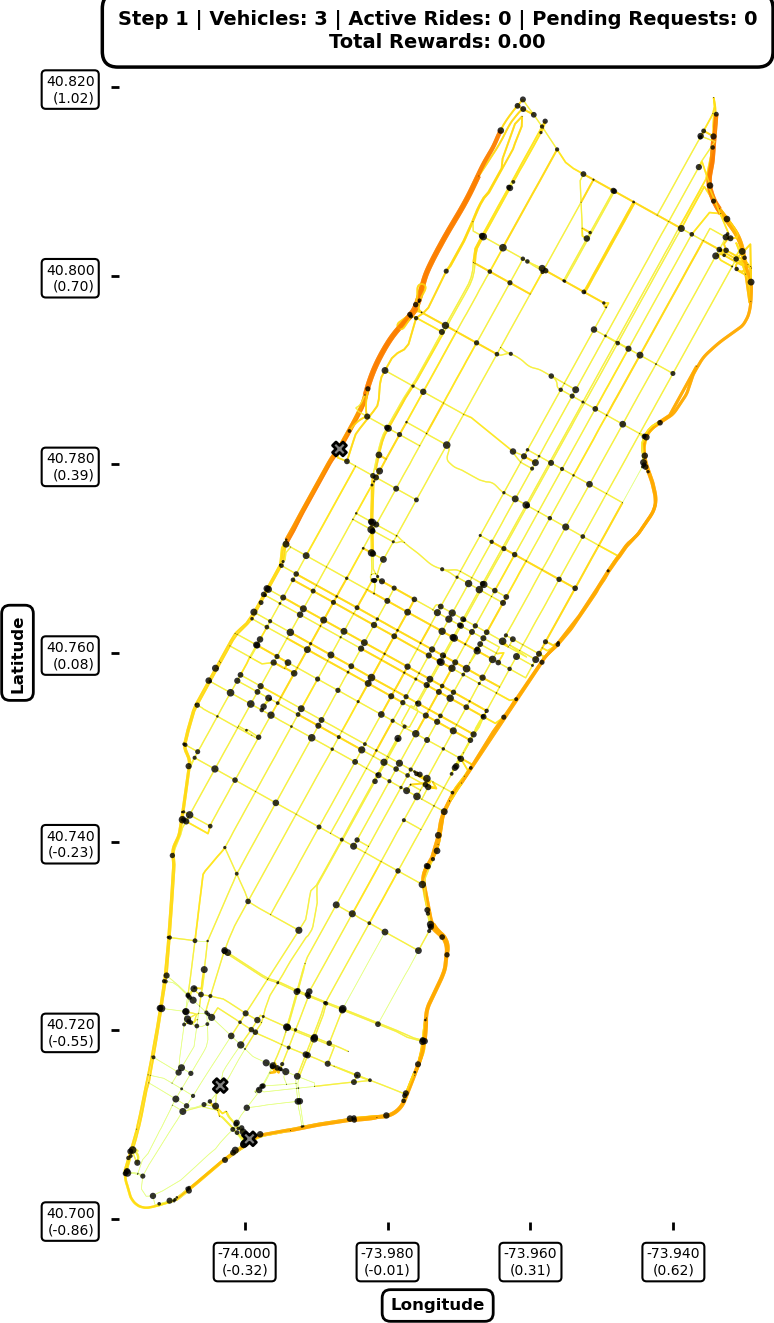

In [27]:
fig, ax = env.render()
fig